## RED NEURONAL CONVOLUCIONAL

En este notebook implementaremos una **Red Neuronal Convoluciona (CNN)**. Esta arquitectura aprovecha la jerarquía espacial de las imágenes de Fashion-MNIST mediante una capa convolucional y la operación *Global Average Pooling (GAP).*

In [13]:

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score
from tensorflow.keras.datasets import fashion_mnist
from keras.optimizers import Adam
import random

random.seed(10)

# 1. Carga de datos
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist.load_data()

# 2. Preprocesamiento: Normalización y Reshape para CNN (28, 28, 1)
X_train_full = X_train_full.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

X_train_full = X_train_full.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# 3. División de datos (Entrenamiento, Validación, Test)
X, X_val, y, y_val = train_test_split(X_train_full, y_train_full,
                                      test_size=0.2, random_state=42,
                                      stratify=y_train_full)

print(f"X (Train): {X.shape}, X_val: {X_val.shape}, X_test: {X_test.shape}")

X (Train): (48000, 28, 28, 1), X_val: (12000, 28, 28, 1), X_test: (10000, 28, 28, 1)


In [14]:
import numpy as np
import cv2

def resaltar_caracteristicas_canny_sobel(X):
    X_3c = np.zeros((X.shape[0], 28, 28, 3), dtype=np.float32)
    
    for i in range(X.shape[0]):
        # Aseguramos que la imagen base sea la original normalizada
        img = X[i, :, :, 0]
        X_3c[i, :, :, 0] = img
        
        # CANAL 1: Sobel Combinado (Magnitud del gradiente)
        # Resalta el "volumen" de la prenda
        sx = cv2.Sobel(img, cv2.CV_32F, 1, 0, ksize=3)
        sy = cv2.Sobel(img, cv2.CV_32F, 0, 1, ksize=3)
        mag = np.sqrt(sx**2 + sy**2)
        X_3c[i, :, :, 1] = cv2.normalize(mag, None, 0, 1, cv2.NORM_MINMAX)
        
        # CANAL 2: Canny Edge Detection
        # Para Canny, OpenCV suele preferir imágenes en formato 8-bit (0-255)
        img_8bit = (img * 255).astype(np.uint8)
        # Los umbrales (100, 200) son un buen punto de partida para Fashion MNIST
        edges = cv2.Canny(img_8bit, 100, 200)
        X_3c[i, :, :, 2] = edges.astype(np.float32) / 255.0
        
    return X_3c

# Aplicar la nueva transformación
x_train_canny = resaltar_caracteristicas_canny_sobel(X)
x_val_canny = resaltar_caracteristicas_canny_sobel(X_val)
x_test_canny = resaltar_caracteristicas_canny_sobel(X_test)

##2. Definición del Modelo CNN

Diseñaremos una arquitectura basada en Redes Neuronales Convolucionales (CNN) siguiendo el principio de mínima complejidad. La convolución utiliza filtros locales que permiten capturar patrones espaciales y texturas, elementos clave en imágenes de prendas de ropa.

La arquitectura propuesta es un ejercicio de eficiencia extrema que utiliza:

1. **Capa Convolucional:** Con kernels de $3 \times 3$ para extraer rasgos característicos (bordes, uniones, tramas).
2. **Activación ReLU:** Para introducir la no linealidad necesaria que permite distinguir formas complejas.
3. **Global Average Pooling (GAP):** En lugar de aplanar la imagen y usar capas densas (que dispararían el número de parámetros), el GAP reduce cada mapa de características a su promedio, conectando directamente con la salida.



In [15]:
import sys
from pathlib import Path


PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

print(f"Raíz del proyecto añadida: {PROJECT_ROOT}")


Raíz del proyecto añadida: d:\Uni\Aprendizaje profundo\ProyectoAP


## 3. Entrenamiento

Entrenamos el modelo y visualizamos las curvas de aprendizaje.

In [16]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Versión optimizada para 3 canales
datagen = ImageDataGenerator(
    rotation_range=8,
    width_shift_range=0.08,
    height_shift_range=0.08,
    zoom_range=0.08,
    horizontal_flip=True, # <-- Crucial para generalizar camisas/abrigos
    fill_mode='nearest'   # Rellena los píxeles vacíos tras rotar/desplazar
)

# ¡IMPORTANTE! Deben hacer el fit sobre los datos de 3 canales
datagen.fit(x_train_3c)

In [17]:
# 1. Importación correcta (asegúrate de que esta celda se ejecute)
from models.CNN_compleja import create_fashion_cnn_v3, get_focal_loss
from keras.optimizers import Adam
import tensorflow as tf

# 2. Configuración y Entrenamiento
model = create_fashion_cnn_v3()

model.compile(
    #optimizer=Adam(learning_rate=0.01),
    optimizer='adam',
    loss=get_focal_loss(gamma=2.5),
    metrics=['accuracy']
)

class_weights = {
0: 1.2,  # T-shirt
1: 1.0,  # Trouser
2: 1.4,  # Pullover
3: 1.0,  # Dress
4: 1.2,  # Coat
5: 1.0,  # Sandal
6: 1.4,  # Shirt (la peor)
7: 1.0,  # Sneaker
8: 1.0,  # Bag
9: 1.0   # Ankle boot
}


# Definir Callbacks
callbacks = [
    tf.keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1),
    tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True)
]

# Entrenar (Recuerden que x_train_3c tiene 3 canales ahora)
history = model.fit(
    x_train_3c, y,
    epochs=20,
    batch_size=64,
    validation_data=(x_val_3c, y_val),
    class_weight=class_weights,
    callbacks=callbacks
)


Epoch 1/20


d:\Uni\Aprendizaje profundo\ProyectoAP\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


750/750 ━━━━━━━━━━━━━━━━━━━━ 15s 18ms/step - accuracy: 0.7296 - loss: 0.1016 - val_accuracy: 0.8608 - val_loss: 0.0369 - learning_rate: 0.0010
Epoch 2/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.8360 - loss: 0.0507 - val_accuracy: 0.8758 - val_loss: 0.0307 - learning_rate: 0.0010
Epoch 3/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.8610 - loss: 0.0416 - val_accuracy: 0.8859 - val_loss: 0.0276 - learning_rate: 0.0010
Epoch 4/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.8740 - loss: 0.0370 - val_accuracy: 0.8708 - val_loss: 0.0317 - learning_rate: 0.0010
Epoch 5/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.8803 - loss: 0.0339 - val_accuracy: 0.9013 - val_loss: 0.0240 - learning_rate: 0.0010
Epoch 6/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.8867 - loss: 0.0315 - val_accuracy: 0.8997 - val_loss: 0.0228 - learning_rate: 0.0010
Epoch 7/20
750/750 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step - accuracy: 0.8932 - loss: 0.0295

## 4. Matriz de Confusión

Visualizamos dónde se confunde el modelo utilizando el conjunto de test.

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


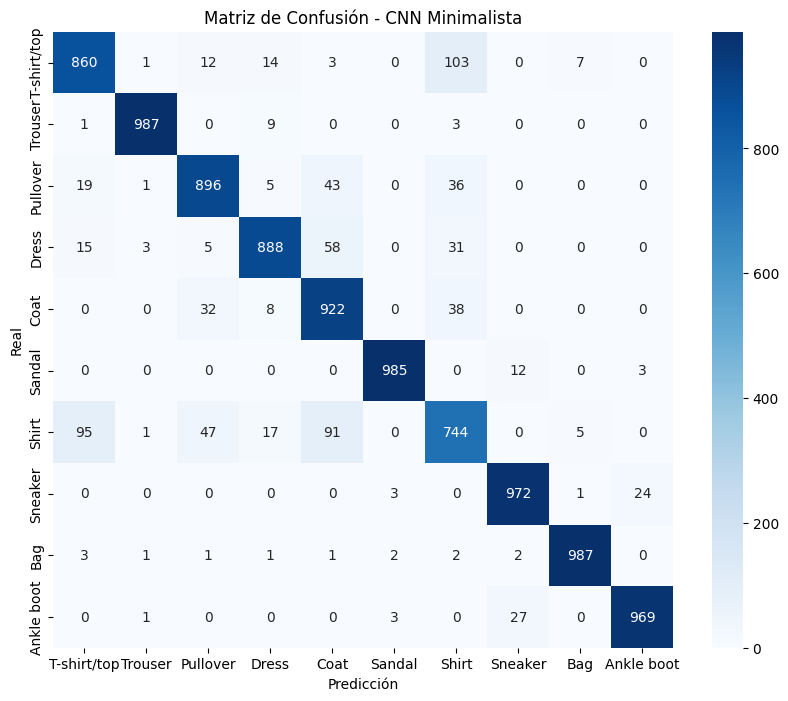

In [18]:
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

y_pred = np.argmax(model.predict(x_test_3c), axis=1)
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Matriz de Confusión - CNN Minimalista')
plt.xlabel('Predicción')
plt.ylabel('Real')
plt.show()

## 5. Evaluación Final

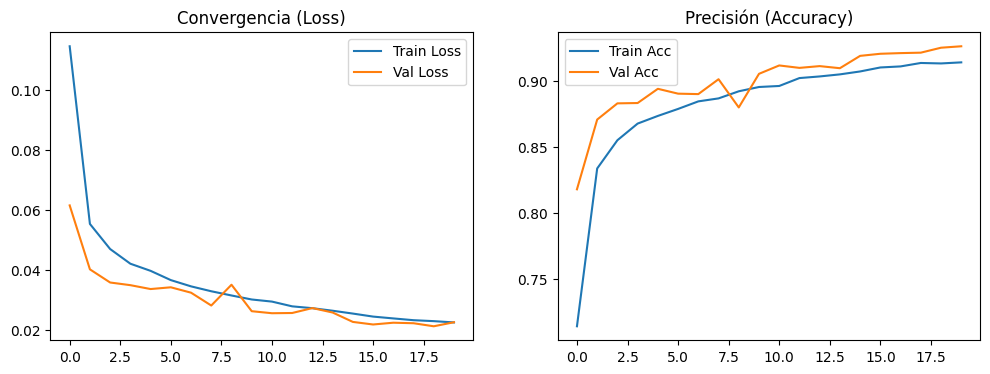

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step

--- RESULTADOS FINALES ---
Train Acc: 0.9140 | Val Acc: 0.9262 | Test Acc: 0.9173
Parámetros: 74986


In [5]:
# Curvas de Aprendizaje
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Convergencia (Loss)')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.title('Precisión (Accuracy)')
plt.legend()
plt.show()

# Evaluación en Test
y_pred = np.argmax(model.predict(X_test), axis=1)
test_acc = accuracy_score(y_test, y_pred)
train_acc = history.history['accuracy'][-1]
val_acc = history.history['val_accuracy'][-1]

print(f"\n--- RESULTADOS FINALES ---")
print(f"Train Acc: {train_acc:.4f} | Val Acc: {val_acc:.4f} | Test Acc: {test_acc:.4f}")
print(f"Parámetros: {model.count_params()}")

## Resumen de Resultados - CNN

| Modelo | Parámetros |Train Acc | Val Acc | Test Acc
| :--- | :---: | :---: | :---: |:---
| **CNN** | 1,726 | 0.8490 | 0.8454 | 0.8395

### Análisis del Modelo CNN

Hemos construido una Red CNN sencilla con solo 2 capas convulucionales y global_average_pooling2d.

Al principio había bastante cuello de botella ya que la red obtenía mejores resultados en validación en la primeras épocas, después ya se estabilizaba.
Al ajustar el learning rate a 0.01 y el orden correcto del los filtros en las capas convulucionales, vemos una mejora significativa.

Se observa que el modelo no es tan preciso con clases que son muy similares.
Nuestro principal reto será conseguir que el modelo clasifique bien las clases muy similares como Camisas y Abrigos.

Podremos añadir más capas al modelo y/o probar funciones de perdida ajustadas para penalizar más los errores en las clases muy similares.
